# Synthetic 2D Data: Principal Component Geometry

## Project Overview

This notebook uses two-dimensional synthetic datasets to make PCA geometry directly visible.

The experiments progressively change feature scale and correlation structure, then inspect how the learned principal directions, transformed coordinates, means, and explained variances respond.

### Technical Coverage

- isotropic two-dimensional Gaussian data
- feature-scale anisotropy
- strong positive correlation
- moderate positive correlation
- negative correlation
- PCA rotation into principal-component space
- component-direction visualization
- component matrix
- data mean
- explained variance

## 1. Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## 2. Isotropic Gaussian Data

A two-dimensional standard-normal sample provides the baseline case, where the two directions have similar variance and no imposed correlation.

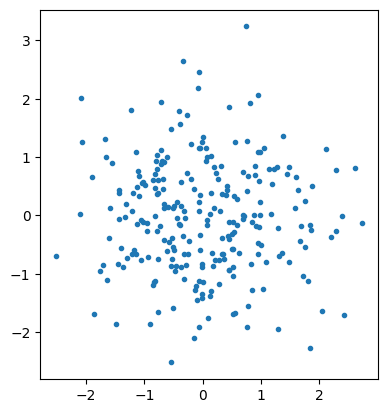

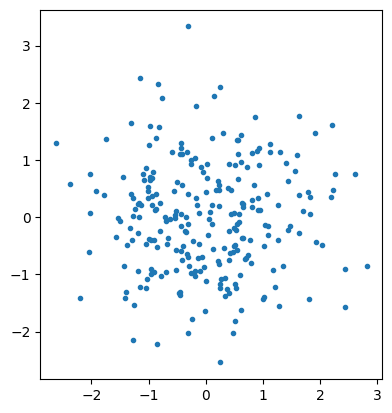

[[ 0.95087513 -0.30957468]
 [ 0.30957468  0.95087513]]
[ 0.01558441 -0.02946093]
[1.05380555 0.93054219]


In [2]:
n = 250
X = np.random.normal(size=(n,2))

plt.figure()
plt.plot(X[:,0],X[:,1],'.')
plt.axis('scaled')
plt.show()

pca = PCA()       # Fit PCA to the two-dimensional sample
pca.fit(X)  # Estimate the principal directions
Xpc = pca.transform(X)

plt.figure()
plt.plot(Xpc[:,0],Xpc[:,1],'.')
plt.axis('scaled')
plt.show()

print(pca.components_)
print(pca.mean_)
print(pca.explained_variance_)

## 3. Unequal Feature Scales

The second coordinate is multiplied by two, creating substantially greater variance along that dimension. PCA aligns its first component with the dominant variance direction.

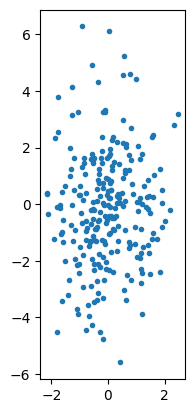

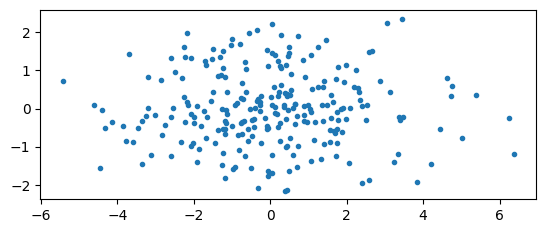

[[ 0.04821331  0.99883706]
 [ 0.99883706 -0.04821331]]
[-0.03496429 -0.13557935]
[4.04966606 0.9227828 ]


In [3]:
n = 250
X = np.random.normal(size=(n,2))
X[:,1] = 2*X[:,1]

plt.figure()
plt.plot(X[:,0],X[:,1],'.')
plt.axis('scaled')
plt.show()

pca = PCA()       # Fit PCA to the anisotropic sample
pca.fit(X)  # Estimate the principal directions
Xpc = pca.transform(X)

plt.figure()
plt.plot(Xpc[:,0],Xpc[:,1],'.')
plt.axis('scaled')
plt.show()

print(pca.components_)
print(pca.mean_)
print(pca.explained_variance_)

## 4. Strong Positive Correlation

The first feature is amplified by a factor of ten and then added to the second feature. This produces a strongly elongated point cloud with a dominant diagonal principal direction.

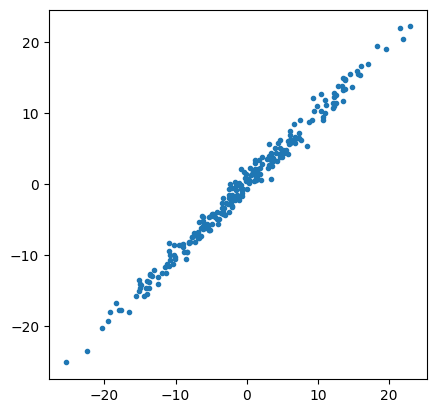

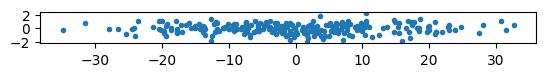

[[ 0.70694079  0.70727273]
 [ 0.70727273 -0.70694079]]
[-0.58215079 -0.5123359 ]
[161.8988799    0.49439998]


In [4]:
n = 250
X = np.random.normal(size=(n,2))
X[:,0] = 10*X[:,0]
X[:,1] += X[:,0]


plt.figure()
plt.plot(X[:,0],X[:,1],'.')
plt.axis('scaled')
plt.show()

pca = PCA()       # Fit PCA to the strongly correlated sample
pca.fit(X)  # Estimate the principal directions
Xpc = pca.transform(X)

plt.figure()
plt.plot(Xpc[:,0],Xpc[:,1],'.')
plt.axis('scaled')
plt.show()

print(pca.components_)
print(pca.mean_)
print(pca.explained_variance_)

## 5. Moderate Positive Correlation

The second coordinate receives half of the first coordinate, producing a milder positive correlation. The original data and PCA-transformed coordinates are shown side by side.

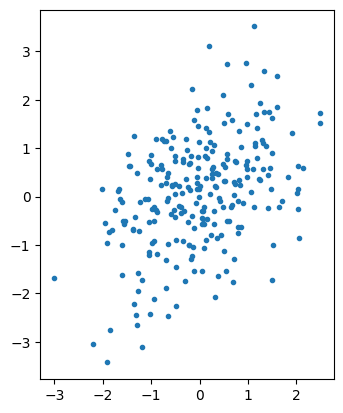

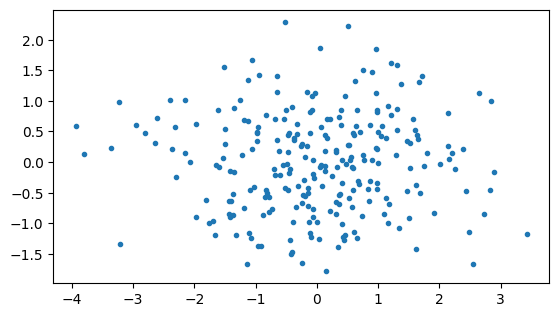

[[ 0.60219291  0.79835061]
 [ 0.79835061 -0.60219291]]
[-0.01310077  0.07299435]
[1.68528822 0.65626513]


In [5]:
n = 250
X = np.random.normal(size=(n,2))
X[:,1] += X[:,0]/2

plt.figure()
plt.plot(X[:,0],X[:,1],'.')
plt.axis('scaled')
plt.show()

pca = PCA()       # Fit PCA to the positively correlated sample
pca.fit(X)  # Estimate the principal directions
Xpc = pca.transform(X)

plt.figure()
plt.plot(Xpc[:,0],Xpc[:,1],'.')
plt.axis('scaled')
plt.show()

print(pca.components_)
print(pca.mean_)
print(pca.explained_variance_)

## 6. Negative Correlation and Principal Axes

The second coordinate is adjusted by subtracting half of the first coordinate. The learned PCA component directions are overlaid on the original point cloud before displaying the transformed representation.

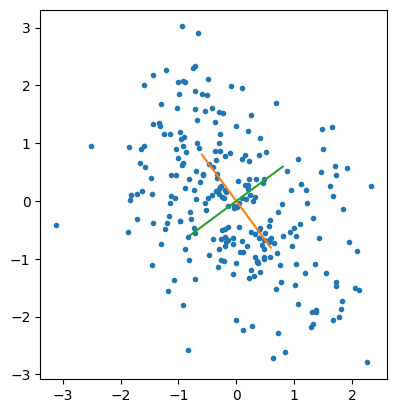

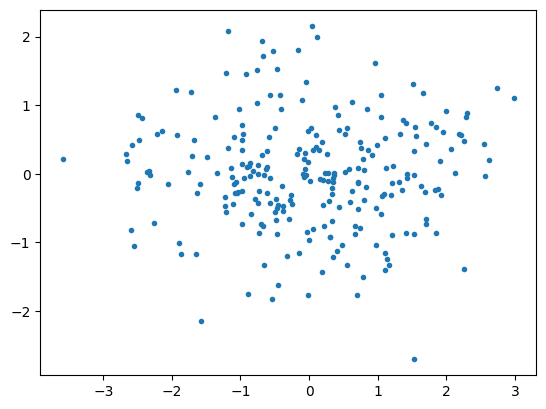

[[-0.59501672  0.80371332]
 [ 0.80371332  0.59501672]]
[-0.04700705 -0.03697942]
[1.60363415 0.63684257]


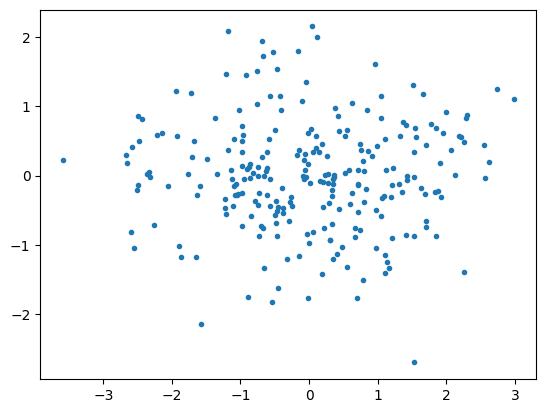

In [6]:
n = 250
X = np.random.normal(size=(n,2))
X[:,1] -= X[:,0]/2

plt.figure()
plt.plot(X[:,0],X[:,1],'.')
plt.axis('scaled')


pca = PCA()       # Fit PCA to the negatively correlated sample
pca.fit(X)  # Estimate the principal directions
Xpc = pca.transform(X)

W = pca.components_
plt.plot([-W[0,0],W[0,0]],[-W[0,1],W[0,1]])
plt.plot([-W[1,0],W[1,0]],[-W[1,1],W[1,1]])

plt.figure()
plt.plot(Xpc[:,0],Xpc[:,1],'.')
plt.axis('scaled')

plt.show()
plt.plot(Xpc[:,0],Xpc[:,1],'.')

print(pca.components_)
print(pca.mean_)
print(pca.explained_variance_)

W = pca.components_

## 7. Key Findings

- PCA aligns its first axis with the direction of greatest sample variance.
- Changing only feature scale can rotate the dominant principal direction.
- Strongly correlated features create a large first explained variance and a much smaller second explained variance.
- Positive and negative correlation produce correspondingly rotated principal axes.
- In the transformed PCA space, the coordinates are aligned with the learned variance directions.